In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore")

In [3]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('Mall_Customers.csv')
df.head()

Saving Mall_Customers.csv to Mall_Customers.csv


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [6]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


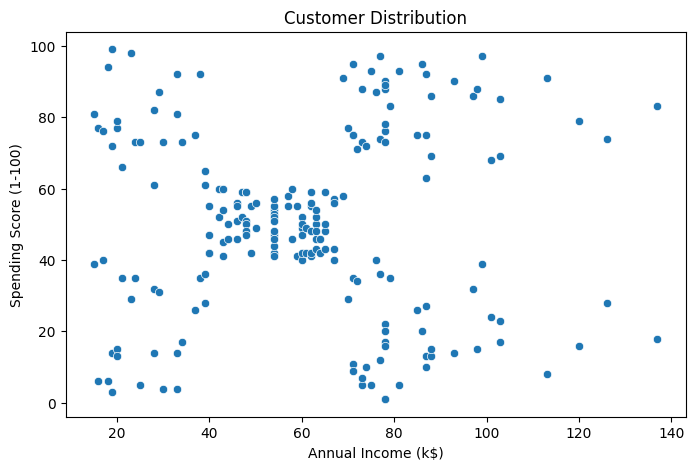

In [7]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data = df,
    x = "Annual Income (k$)",
    y = "Spending Score (1-100)"
)
plt.title("Customer Distribution")
plt.show()

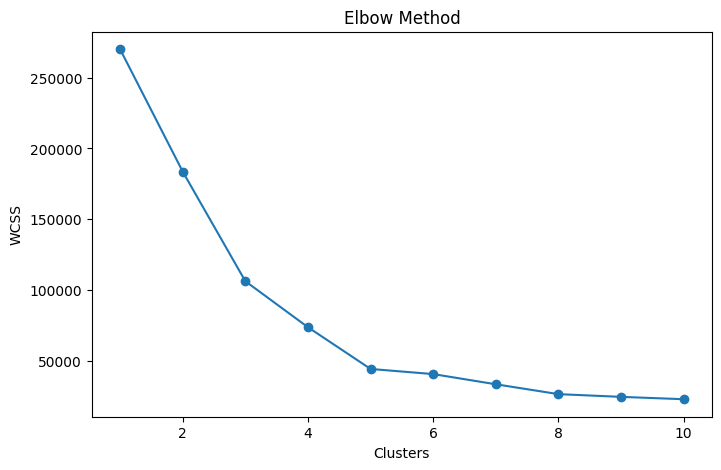

In [8]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]
wcss = []
for i in range (1,11):
  model = KMeans(
      n_clusters = i,
      random_state = 42
  )
  model.fit(X)
  wcss.append(model.inertia_)
plt.figure(figsize=(8,5))
plt.plot(range(1,11),wcss,marker="o")
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [9]:
kmeans = KMeans(
    n_clusters = 5,
    random_state = 42
)
df["Cluster"] = kmeans.fit_predict(X)
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


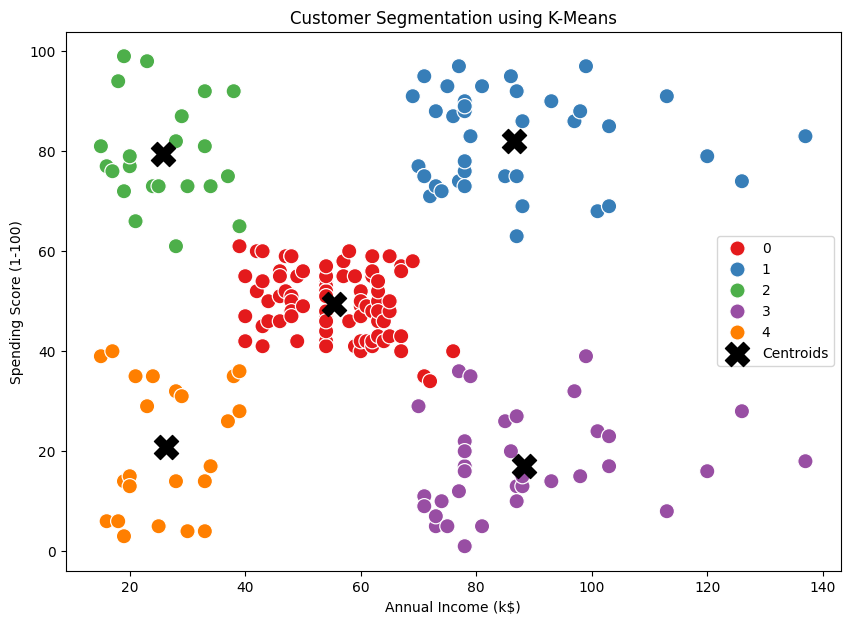

In [10]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="Set1",
    s=120
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    c="black",
    s=300,
    marker="X",
    label="Centroids"
)

plt.title("Customer Segmentation using K-Means")

plt.legend()

plt.show()

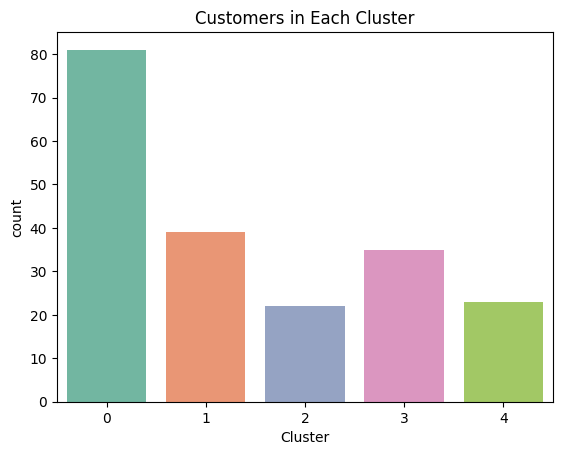

In [11]:
sns.countplot(
    data=df,
    x="Cluster",
    palette="Set2"
)

plt.title("Customers in Each Cluster")

plt.show()

In [12]:
summary = df.groupby("Cluster")[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]].mean()

summary

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


In [13]:
print("""
Business Insights

Cluster 0:
High Income - High Spending
Premium Customers

Cluster 1:
Low Income - High Spending
Potential Customers

Cluster 2:
Average Income - Average Spending
Regular Customers

Cluster 3:
High Income - Low Spending
Target for Marketing

Cluster 4:
Low Income - Low Spending
Occasional Customers
""")


Business Insights

Cluster 0:
High Income - High Spending
Premium Customers

Cluster 1:
Low Income - High Spending
Potential Customers

Cluster 2:
Average Income - Average Spending
Regular Customers

Cluster 3:
High Income - Low Spending
Target for Marketing

Cluster 4:
Low Income - Low Spending
Occasional Customers

